<a href="https://colab.research.google.com/github/mahathi-kannan/CodeAlpha_Iris_Flower_Classification/blob/main/iris_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Sample (First 5 Rows) ---
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Target classes identified: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Training the Random Forest Classifier...

Model Accuracy: 90.00%

--- Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90 

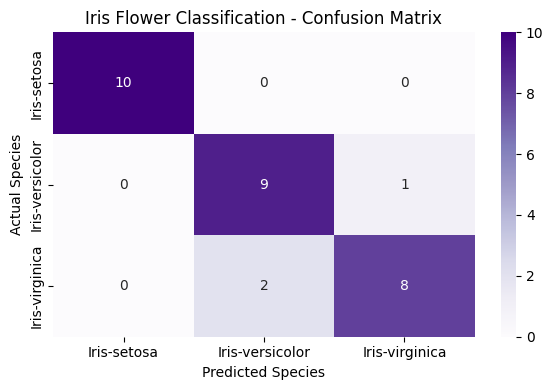

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the locally uploaded dataset

df = pd.read_csv('Iris.csv')

print("--- Dataset Sample (First 5 Rows) ---")
print(df.head())

# 2. Separate Features (X) and Target (y)
# We drop 'Id' (unnecessary index) and 'Species' (the target label)
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

# 3. Encode categorical labels ('Iris-setosa', etc.) into numbers (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nTarget classes identified:", le.classes_)

# 4. Split the Data into Training and Testing Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 5. Train the Machine Learning Model
print("\nTraining the Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Make Predictions
y_pred = model.predict(X_test)

# 7. Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 8. Visualize the Results (Confusion Matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Iris Flower Classification - Confusion Matrix')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.tight_layout()
plt.show()